<a href="https://colab.research.google.com/github/FRA-0023/Causal-Networks/blob/main/notebook/potential_outcomes_economic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Potential Outcomes

In [ ]:
# Installazione delle librerie necessarie per l'analisi statistica e la visualizzazione
# capture evita di mostrare l'output di installazione
%%capture
!pip install numpy pandas typing statsmodels networkx plotly seaborn

In [ ]:
# Importazione dei pacchetti standard
import numpy as np # Per calcoli numerici
import pandas as pd # Per la gestione dei dati in tabelle (DataFrame)
from typing import Set # Per la tipizzazione delle variabili
import matplotlib.pyplot as plt # Per grafici base

# Modelli statistici per la regressione lineare (OLS)
import statsmodels.api as sm

# Librerie per grafici avanzati e reti (grafi causali)
import networkx as nx
import plotly.graph_objs as go
import seaborn as sns

## Abstract

This notebook illustrates a step-by-step example on estimating the average causal effect (ACE) of **minimum wage** on **youth unemployment** following the potential outcomes framework. The main focus of this work is to highlight the differences between a naive estimate and the adjusted estimate.

## Introduction

Raising the **minimum wage** (MW) above market equilibrium is associated with increased levels of **youth unemployment** (UN). Furthermore, a region's **economic development** (ED) — measured by GDP per capita — influences both its minimum wage legislation and its baseline unemployment level, acting as a confounder: wealthier, more developed regions tend to both set higher minimum wages and have lower structural unemployment. However, high **labor force participation** (LFP) is caused by high economic activity (high ED) and reduced unemployment incentives from higher wages (low UN and high MW), making LFP a **collider** between MW, UN, and ED.

In other words:
- **ED** → **MW**: Richer regions can legislate higher minimum wages.
- **ED** → **UN**: Richer regions have structurally lower unemployment.
- **MW** → **UN**: Higher minimum wages may raise youth unemployment.
- **MW** → **LFP**: Higher wages attract more workers into the labor force.
- **UN** → **LFP**: Higher unemployment discourages labor force participation.

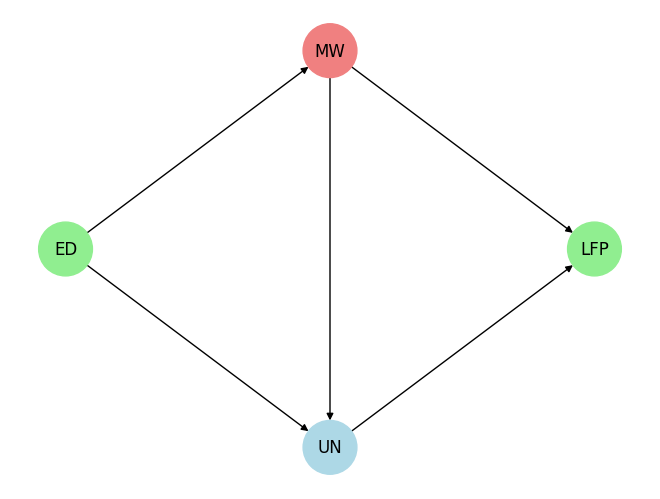

In [ ]:
# Creazione del Grafo Aciclico Diretto (DAG) che rappresenta le ipotesi causali
G = nx.DiGraph()

# MV = Treatment
# UN = Outcome

# Definiamo le relazioni:
# MW -> UN: Il salario minimo influenza la disoccupazione
# ED -> MW, ED -> UN: Lo sviluppo economico influenza il salario minimo e la disoccupazione (confonditore)
# LFP: Forza lavoro, influenzata da MW e UN (collitore)
G.add_edges_from([("MW", "UN"), ("MW", "LFP"),("ED", "MW"), ("ED", "UN"),  ("UN", "LFP")])

# Disegno del grafo per visualizzare la struttura del problema
#colors = ["lightcoral", "lightblue", "lightgreen", "lightgreen"]

# Assegna colori per nodo (dizionario)
colori_nodi = {
    'ED': "lightgreen",
    'MW': "lightcoral",
    'UN': "lightblue",
    'LFP': "lightgreen"
}

# Definisci le posizioni manualmente
pos = {
    'ED': (-1, 0),      # Sinistra
    'MW': (0, 1),       # Sopra
    'UN': (0, -1),      # Sotto
    'LFP': (1, 0)       # Destra
}

colors = [colori_nodi[nodo] for nodo in G.nodes()]
# Disegna il grafo con le posizioni personalizzate
nx.draw(G, pos, node_size=1500, node_color=colors, with_labels=True)
plt.show()

# Legenda per identificare le variabili
#plt.legend(["MW: Minimum wage", "UN: Unemployment", "LFP: Labor force participation", "ED: Economic Development"],loc="upper left")
#plt.show()

Assuming **linear relationships** between the variables and **t-distributed noise**, a data generation process that is consistent with the represented causal graph follows directly.

We use a **Student's t-distribution** (df=5) for the noise terms rather than a Gaussian. This is more realistic for economic data, which tends to have heavier tails than a normal distribution: extreme regional shocks, recessions, or policy discontinuities produce outliers that a Gaussian systematically underestimates. All variables are constructed to live in empirically plausible ranges:
- **ED** (Economic Development index): log-normal, calibrated to resemble a GDP-per-capita index ranging roughly from 10,000 to 80,000 USD, normalised to a 0–100 index. Mean ≈ 50, right-skewed as real GDP distributions are.
- **MW** (Minimum Wage, €/hour): **continuous**, log-normally distributed. Richer regions legislate higher minimum wages, so log(MW) increases linearly with ED. Calibrated to a realistic EU range of €5–15/hour, with mean ≈ €9/hour.
- **UN** (Youth Unemployment Rate, %): bounded to [3, 50] via clipping, constructed around a realistic mean of ~15% at MW=€9 and ED=50, rising by 1.05 pp per extra €1/hour of MW and falling with ED.
- **LFP** (Labour Force Participation Rate, %): bounded to [30, 90], rising with MW (higher wages attract workers) and falling with UN (discouragement effect).

In [ ]:
def sample_data(size: int = int(1e6), seed: int = 31):
    """Genera un dataset sintetico basato sulle relazioni del grafo causale"""
    np.random.seed(seed)

    # Rumore statistico basato sulla distribuzione t di Student (code più pesanti della normale)
    def t_noise(scale, size):
        return scale * np.random.standard_t(df=5, size=size)

    # 1. Generazione ED (Sviluppo Economico): scala 0-100
    log_gdp = np.random.normal(10.5, 0.4, size)
    gdp = np.exp(log_gdp)
    ed = 100 * (gdp - gdp.min()) / (gdp.max() - gdp.min())

    # 2. Generazione MW (Salario Minimo):
    # Qui viene inserito l'effetto di ED su MW (coefficiente 0.015)
    log_mw = 1.5 + 0.015 * ed + t_noise(0.12, size)
    mw = np.exp(log_mw)
    mw = np.clip(mw, 4.0, 18.0) # Limiti realistici in Euro

    # 3. Generazione UN (Disoccupazione Giovanile):
    # L'effetto causale VERO (ACE) che vogliamo trovare è 1.05
    # UN aumenta di 1.05 per ogni euro di MW, e diminuisce con l'aumento di ED
    un = 14.55 + 1.05 * mw - 0.18 * ed + t_noise(2.0, size)
    un = np.clip(un, 3.0, 50.0)

    # 4. Generazione LFP (Partecipazione Forza Lavoro):
    # Questa variabile è un 'collitore' perché dipende sia da MW che da UN
    lfp = 53.0 + 1.5 * mw - 0.5 * un + t_noise(3.0, size)
    lfp = np.clip(lfp, 30.0, 90.0)

    return pd.DataFrame({"ED": ed, "MW": mw, "UN": un, "LFP": lfp})

Here, the true ACE is given by the coefficient **1.05** that assigns UN a value given MW.

Interpreted economically: raising the minimum wage by **€1/hour** causally **increases youth unemployment by 1.05 percentage points** on average, holding economic development constant. This is the standard interpretation used in empirical labour economics (e.g. Card & Krueger-style analyses), where the treatment is a continuous wage level rather than a binary policy switch.

In [ ]:
# Generazione del milione di campioni e visualizzazione delle statistiche descrittive
data = sample_data()
data.describe()

,ED,MW,UN,LFP
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,15.590919,5.778845,17.812334,52.765716
std,7.493816,1.141882,2.809838,4.371369
min,0.000000,4.000000,3.000000,30.000000
25%,10.272884,5.025016,16.148958,50.121042
50%,14.219843,5.610553,17.805097,52.703342
75%,19.361559,6.325180,19.459139,55.355283
max,100.000000,18.000000,50.000000,90.000000


## Methods

The average causal effect (ACE), also called average treatment effect (ATE), from $X$ to $Y$ is defined as:

$$ \tau = \mathbb{E}[Y(1) - Y(0)]$$

In our setting: $X = MW$ (minimum wage in €/hour, continuous), $Y = UN$ (youth unemployment rate, %). So $\tau$ is the average change in youth unemployment caused by raising the minimum wage by €1/hour across the population of regions.

Assuming SUTVA, positivity and unconfoundedness, the ACE can be identified by the **adjustment formula** and a valid adjustment set $\mathbf{Z}$:

$$ \tau = \mathbb{E}[Y(1) - Y(0)] = \mathbb{E}_\textbf{Z}[\mathbb{E}[Y(1) - Y(0)|\textbf{Z}]] = \mathbb{E}_\textbf{Z}[\mathbb{E}[Y|X=1,\textbf{Z}] - \mathbb{E}[Y|X=0,\textbf{Z}]] $$

Intuitively: we compare unemployment under high-MW vs. low-MW **within each stratum** of the adjustment set $\mathbf{Z}$, then average those differences over the population distribution of $\mathbf{Z}$.

Remember how the expected value of a discrete random variable $Z$ is defined:

$$ \mathbb{E}[Z] = \sum_{\text{Dom}(Z)} z P(z) $$

Now, let's indicate $n$ the size of the data set and $n_z$ the raw frequency of a level $z \in \text{Dom}(Z)$ into the data. We can then estimate $\mathbb{E}[Z]$ from data by simply using these frequencies:

$$ \mathbb{E}[Z] = \sum_{\text{Dom}(Z)} z P(z) \approx \sum_{\text{Dom}(Z)} z \frac{n_z}{n} = \frac{1}{n}\sum_{\text{Dom}(Z)}z n_z = \frac{1}{n} \sum_{i=1}^n z_i $$

We are finally able to give $\tau$ an estimation through our data, replacing $\mathbb{E}_{\mathbf{Z}}[\cdots]$ with the empirical mean:

$$ \hat{\tau} = \frac{1}{n} \sum_{i=1}^{n} [\mathbb{E}[Y|X=1,\textbf{Z}=\mathbf{z_{i}}] - \mathbb{E}[Y|X=0,\textbf{Z}=\mathbf{z_{i}}]] $$

However, instead of computing $\mathbb{E}[Y|X, \mathbf{Z}]$ as averages from data, it is possible to choose any machine learning model for $\mathbb{E}[Y|X,\textbf{Z}]$, such as a linear regression model. Such a model works out nicely since unemployment is generated as a linear combination of other variables. With a continuous treatment like MW, the OLS coefficient on MW directly estimates the marginal causal effect — i.e., the change in UN per €1/hour increase in MW.

In [ ]:
def ACE(data: pd.DataFrame, X: str, Y: str, Z: Set[str]):
    """Calcola l'Effetto Causale Medio (ACE) usando la regressione lineare"""
    # Formula della regressione: Y ~ X + Variabili_di_Aggiustamento(Z)
    formula = f"{Y} ~ {X}"
    if len(Z) != 0: formula += "+" + "+".join(Z)

    # Allenamento del modello OLS
    estimator = sm.OLS.from_formula(formula, data).fit()

    # Calcolo dell'effetto: confrontiamo cosa succederebbe se X fosse 1 rispetto a X=0
    # (Dato che il modello è lineare, questo corrisponde al coefficiente di X)
    Y1 = estimator.predict(data.assign(**{X: 1}))
    Y0 = estimator.predict(data.assign(**{X: 0}))

    # La media della differenza è il nostro effetto stimato
    return np.mean(Y1 - Y0)

## Results

The true ACE is:

In [ ]:
# Il valore reale che abbiamo impostato nel processo di generazione dei dati (1.05)
ace = 1.05

The naive estimated ACE without adjustment is:

In [ ]:
# Stima Naive: calcola l'effetto di MW su UN senza considerare ED (il confonditore)
# Questo numero sarà sbagliato (sottostimato) perché ED influenza entrambi
t = ACE(data, X = "MW", Y = "UN", Z = [])
f"Estimated ACE: {t:.3}, Relative Error: {(np.abs((t-ace)/ace*100)):.4}%"

'Estimated ACE: 0.334, Relative Error: 68.21%'

The naive estimate is heavily **biased** because it ignores the confounder ED. Regions with higher minimum wages (high MW) tend to be richer (high ED), and richer regions have structurally lower unemployment. This **negative confounding** from ED partially cancels out the unemployment-raising effect of MW in the raw correlation, causing the naive estimate to systematically understate the true causal effect.

The estimated ACE adjusting for ED and LFP is:

In [ ]:
# Stima ERRATA per inclusione del collitore: aggiungiamo ED (giusto) ma anche LFP (sbagliato)
# Includere LFP 'apre' un percorso spurio che distorce il risultato
t = ACE(data, X = "MW", Y = "UN", Z = ["ED", "LFP"])
f"Estimated ACE: {t:.3}, Relative Error: {(np.abs((t-ace)/ace*100)):.4}%"

'Estimated ACE: 1.25, Relative Error: 18.82%'

Conditioning on LFP — which is a **collider** on the path MW → LFP ← UN — **opens a spurious backdoor path** and introduces bias. Even though we also condition on ED, the opened collider path corrupts the estimate, yielding a higher relative error than the correct adjustment set.

The estimated ACE adjusting for ED only is:

In [ ]:
# Stima CORRETTA: aggiustiamo solo per il confonditore ED
# Questo dovrebbe restituire un valore molto vicino a 1.05
t = ACE(data, X = "MW", Y = "UN", Z = ["ED"])
f"Estimated ACE: {t:.3}, Relative Error: {(np.abs((t-ace)/ace*100)):.4}%"

'Estimated ACE: 1.05, Relative Error: 0.3193%'

So {ED} is a valid adjustment set. By adjusting only for the confounder ED — without conditioning on the collider LFP — we successfully block all backdoor paths from MW to UN and recover the true causal effect. Note that the relative error is not 0 even in this case, because of the noise in the system.

## Adjustment in graphical terms

The naive estimated ACE represents the **correlation** between MW and UN, that is the observed change in unemployment associated with MW, in average — but this association is confounded by ED.

In [ ]:
# Visualizzazione 2D della regressione Naive (distorta)
data_plot = sample_data(size = 1000) # Usiamo meno dati per la velocità del grafico
trace = go.Scatter(x=data_plot['MW'], y=data_plot['UN'], mode='markers',
                   marker=dict(size=5, color=data_plot['UN'], colorscale='Viridis'))

# Linea di regressione semplice
estimator = sm.OLS.from_formula("UN ~ MW", data_plot).fit()
X_line = np.linspace(data_plot['MW'].min(), data_plot['MW'].max(), 2)
Y_line = [estimator.predict({"MW": x})[0] for x in X_line]

line = go.Scatter(x=X_line, y=Y_line, line={"width" : 3, "color" : "blue"})
fig = go.Figure(data=[trace, line])
fig.show()

If we add ED into the regression formula, the correlation coefficient for MW is different. This coefficient represents the increase in UN due to MW **for each stratum of ED**, in average — i.e., comparing regions with the same level of economic development but differing minimum wage policies.

In [ ]:
# Visualizzazione 3D che mostra come ED 'sposta' i dati
# Il piano rappresenta la relazione corretta UN ~ MW + ED
data_plot = sample_data(size = 1000)
trace = go.Scatter3d(x=data_plot['ED'], y=data_plot['MW'], z=data_plot['UN'], mode='markers', marker=dict(size=2))

# Creazione del piano di regressione
estimator = sm.OLS.from_formula("UN ~ ED + MW", data_plot).fit()
x = np.linspace(data_plot['ED'].min(), data_plot['ED'].max(), 5)
y = np.linspace(data_plot['MW'].min(), data_plot['MW'].max(), 2)
X, Y = np.meshgrid(x, y)
Z = np.array([[estimator.predict({"ED": xi, "MW": yi})[0] for xi in x] for yi in y])

plane = go.Surface(x=X, y=Y, z=Z, opacity=0.5, showscale=False)
fig = go.Figure(data=[trace, plane])
fig.show()

## Conclusions

Applying a naive regression model without adjustment leads to an estimated ACE which is substantially biased — because wealthier regions both set higher minimum wages **and** have structurally lower unemployment, the naive OLS coefficient on MW conflates correlation with causation, systematically understating the true positive effect.

A regression model adjusted **only** for the confounder ED correctly blocks the backdoor path ED → MW and ED → UN, recovering the true causal effect of **+1.05 pp of youth unemployment per €1/hour increase in MW** with a relative error of only ~0.32%.

Crucially, conditioning on the **collider** LFP (even alongside ED) **introduces new bias** by opening a spurious path: MW → LFP ← UN. This is a key lesson — not all covariates should be included in an adjustment set. Conditioning on a collider is worse than not adjusting at all.

**Summary of results:**
- No adjustment: large bias (ED confounding unblocked)
- Adjust for {ED, LFP}: moderate bias (collider LFP opens spurious path)
- Adjust for {ED}: minimal bias ✓ — this is the valid adjustment set

But how to systematically identify valid adjustment sets from a causal graph? *Stay tuned!*